# 06 Performance Analysis

## Objective
Analyse operational service performance across London Underground lines and create supporting context for network fragility findings.

## Inputs
- `data/raw/service-operated.csv`
- `data/raw/kilometres-operated.csv`
- `data/raw/excess-journey-time.csv`
- `data/raw/orr_station_usage.csv`
- `data/raw/trains_planned.csv`

## Outputs
- cleaned performance datasets
- line-level summary tables
- output charts

## Why this step matters
This notebook adds operational context to the structural graph analysis by showing which lines underperform in service delivery and passenger journey quality.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import os

In [2]:
BASE_DIR = Path("..")
RAW_DIR = BASE_DIR / "data" / "raw"
PROCESSED_DIR = BASE_DIR / "data" / "processed"
OUTPUTS_DIR = BASE_DIR / "outputs"

print("RAW_DIR:", RAW_DIR.resolve())
print("PROCESSED_DIR:", PROCESSED_DIR.resolve())
print("OUTPUTS_DIR:", OUTPUTS_DIR.resolve())
print(os.listdir(RAW_DIR))

RAW_DIR: C:\Users\Saisha\OneDrive\Desktop\transport-network-failure-analysis\data\raw
PROCESSED_DIR: C:\Users\Saisha\OneDrive\Desktop\transport-network-failure-analysis\data\processed
OUTPUTS_DIR: C:\Users\Saisha\OneDrive\Desktop\transport-network-failure-analysis\outputs
['excess-journey-time.csv', 'kilometres-operated.csv', 'orr_station_usage.csv', 'service-operated.csv', 'trains_planned.csv']


## Step 1: Clean and analyse service operated data

This measures the percentage of scheduled service that was actually delivered across lines.

In [3]:
service = pd.read_csv(
    RAW_DIR / "service-operated.csv",
    encoding="utf-8-sig",
    usecols=range(9)
)

print(service.shape)
service.head()

(1020, 9)


,Financial Year,Period,Line,Service Operated for Period - Weekday,Service Operated Year to Date - Weekday,Service Operated for Period - Weekend,Service Operated Year to Date - Weekend,Service Operated for Period - All Week,Service Operated Year to Date - All Week
0,2018-19,1,Bakerloo,97.5%,97.5%,96.0%,96.0%,97.1%,97.1%
1,2018-19,1,Central,95.9%,95.9%,97.0%,97.0%,96.2%,96.2%
2,2018-19,1,Circle Hammersmith & City,96.2%,96.2%,96.8%,96.8%,96.3%,96.3%
3,2018-19,1,District,95.7%,95.7%,99.1%,99.1%,96.6%,96.6%
4,2018-19,1,Jubilee,89.1%,89.1%,83.3%,83.3%,87.6%,87.6%


In [4]:
service_percent_cols = [
    "Service Operated for Period - Weekday",
    "Service Operated Year to Date - Weekday",
    "Service Operated for Period - Weekend",
    "Service Operated Year to Date - Weekend",
    "Service Operated for Period - All Week",
    "Service Operated Year to Date - All Week"
]

for col in service_percent_cols:
    service[col] = (
        service[col]
        .astype(str)
        .str.replace("%", "", regex=False)
        .str.strip()
    )
    service[col] = pd.to_numeric(service[col], errors="coerce")

service["Line_clean"] = (
    service["Line"]
    .astype(str)
    .str.lower()
    .str.strip()
    .str.replace("&", "and", regex=False)
)

service.to_csv(PROCESSED_DIR / "service_operated_clean.csv", index=False)
print("Saved service_operated_clean.csv")

Saved service_operated_clean.csv


## Step 2: Clean and analyse kilometres operated data

This compares actual and scheduled service distances to quantify delivery gaps by line.

In [5]:
km = pd.read_csv(
    RAW_DIR / "kilometres-operated.csv",
    encoding="utf-8-sig",
    usecols=range(9)
)

print(km.shape)
km.head()

(1277, 9)


,Financial Year,Period,Line,Actual KMs in Peak,Scheduled KMs in Peak,Actual KMs in Off Peak,Scheduled KMs in Off Peak,Actual KMs Total,Scheduled KMs Total
0,2016-17,1,Bakerloo,"76,446","79,803","232,682","238,264","309,128","318,068"
1,2016-17,1,C&H,"75,814","79,242","257,117","269,366","332,931","348,608"
2,2016-17,1,Central,"281,658","293,652","778,134","788,828","1,059,792","1,082,480"
3,2016-17,1,District,"214,410","220,225","623,936","631,176","838,346","851,400"
4,2016-17,1,Jubilee,"227,387","232,641","663,054","672,295","890,442","904,936"


In [6]:
for col in km.columns:
    if col not in ["Financial Year", "Period", "Line"]:
        km[col] = (
            km[col]
            .astype(str)
            .str.replace(",", "", regex=False)
            .str.strip()
        )
        km[col] = pd.to_numeric(km[col], errors="coerce")

km["Line_clean"] = (
    km["Line"]
    .astype(str)
    .str.lower()
    .str.strip()
    .str.replace("&", "and", regex=False)
)

km.to_csv(PROCESSED_DIR / "kilometres_operated_clean.csv", index=False)
print("Saved kilometres_operated_clean.csv")

Saved kilometres_operated_clean.csv


## Step 3: Clean and analyse excess journey time data

Excess Journey Time captures passenger delay burden and provides a direct service-quality measure.

In [7]:
ejt = pd.read_csv(
    RAW_DIR / "excess-journey-time.csv",
    encoding="utf-8-sig"
)

print("Shape:", ejt.shape)
print("Columns:", ejt.columns.tolist())
ejt.head()

Shape: (510, 6)
Columns: ['Financial Year', 'Period', 'Organisational Name', 'KPI Name', 'EJT for Period', 'EJT Year to Date']


,Financial Year,Period,Organisational Name,KPI Name,EJT for Period,EJT Year to Date
0,2016-17,1,Line Operations - Bakerloo Line,Excess Journey Time - Trains,1.61,1.61
1,2016-17,1,Line Operations - Central Line,Excess Journey Time - Trains,2.72,2.72
2,2016-17,1,Line Operations - Circle and Hammersmith Line,Excess Journey Time - Trains,3.55,3.55
3,2016-17,1,Line Operations - District Line,Excess Journey Time - Trains,2.81,2.81
4,2016-17,1,Line Operations - Jubilee Line,Excess Journey Time - Trains,1.41,1.41


In [8]:
for col in ["Financial Year", "Organisational Name", "KPI Name"]:
    ejt[col] = ejt[col].astype(str).str.strip()

ejt["Period"] = pd.to_numeric(ejt["Period"], errors="coerce")
ejt["EJT for Period"] = pd.to_numeric(ejt["EJT for Period"], errors="coerce")
ejt["EJT Year to Date"] = pd.to_numeric(ejt["EJT Year to Date"], errors="coerce")

ejt["Line"] = (
    ejt["Organisational Name"]
    .str.replace("Line Operations - ", "", regex=False)
    .str.replace(" Line", "", regex=False)
    .str.strip()
)

ejt["Line_clean"] = (
    ejt["Line"]
    .str.lower()
    .str.strip()
    .str.replace("&", "and", regex=False)
)

ejt.to_csv(PROCESSED_DIR / "excess_journey_time_clean.csv", index=False)
print("Saved excess_journey_time_clean.csv")

Saved excess_journey_time_clean.csv


In [9]:
orr_usage = pd.read_csv(RAW_DIR / "orr_station_usage.csv")
orr_usage.columns = [c.strip() for c in orr_usage.columns]

for col in orr_usage.columns:
    if orr_usage[col].dtype == "object":
        orr_usage[col] = orr_usage[col].astype(str).str.strip()

orr_usage.to_csv(PROCESSED_DIR / "orr_station_usage_clean.csv", index=False)
print("Saved orr_station_usage_clean.csv")

Saved orr_station_usage_clean.csv


In [10]:
trains_planned = pd.read_csv(RAW_DIR / "trains_planned.csv")
trains_planned.columns = [c.strip() for c in trains_planned.columns]

for col in trains_planned.columns:
    if trains_planned[col].dtype == "object":
        trains_planned[col] = trains_planned[col].astype(str).str.strip()

trains_planned.to_csv(PROCESSED_DIR / "trains_planned_clean.csv", index=False)
print("Saved trains_planned_clean.csv")

Saved trains_planned_clean.csv


In [11]:
service_line_summary = (
    service.groupby("Line", as_index=False)["Service Operated for Period - All Week"]
    .mean()
    .sort_values("Service Operated for Period - All Week", ascending=True)
)

service_line_summary.head(15)

,Line,Service Operated for Period - All Week
5,Metropolitan,86.934314
8,Piccadilly,88.060784
1,Central,88.452941
2,Circle Hammersmith & City,88.912745
4,Jubilee,89.624510
6,Network,90.611765
0,Bakerloo,90.709804
9,Victoria,90.732353
3,District,92.550000
7,Northern,94.280392


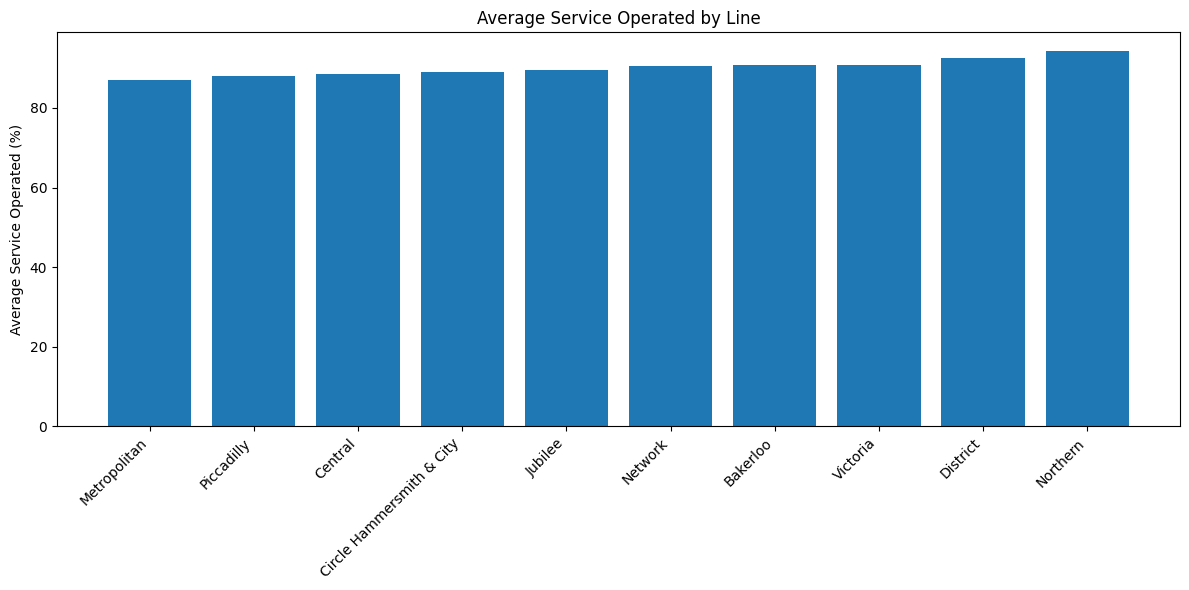

In [12]:
plt.figure(figsize=(12, 6))
plt.bar(
    service_line_summary["Line"],
    service_line_summary["Service Operated for Period - All Week"]
)
plt.xticks(rotation=45, ha="right")
plt.ylabel("Average Service Operated (%)")
plt.title("Average Service Operated by Line")
plt.tight_layout()
plt.savefig(OUTPUTS_DIR / "avg_service_operated_by_line.png")
plt.show()

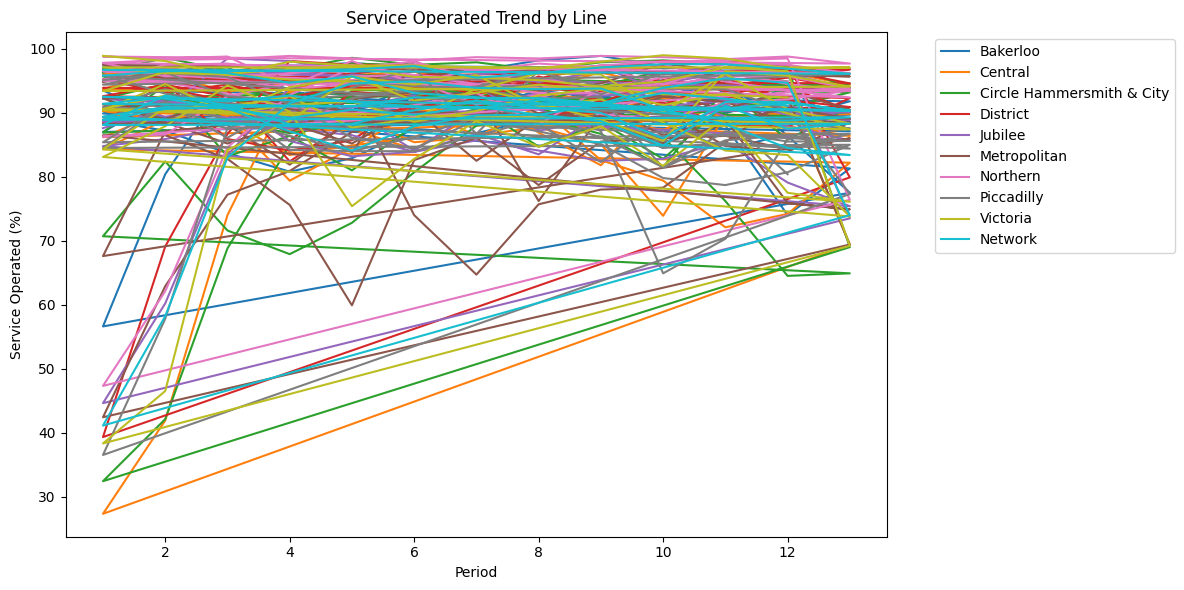

In [13]:
service["Period"] = pd.to_numeric(service["Period"], errors="coerce")

plt.figure(figsize=(12, 6))
for line in service["Line"].dropna().unique():
    subset = service[service["Line"] == line]
    plt.plot(
        subset["Period"],
        subset["Service Operated for Period - All Week"],
        label=line
    )

plt.xlabel("Period")
plt.ylabel("Service Operated (%)")
plt.title("Service Operated Trend by Line")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.savefig(OUTPUTS_DIR / "service_operated_trend_by_line.png")
plt.show()

In [14]:
km_line_summary = (
    km.groupby("Line", as_index=False)["Actual KMs Total"]
    .mean()
    .sort_values("Actual KMs Total", ascending=False)
)

km_line_summary.head(15)

,Line,Actual KMs Total
6,Northern,1.111561e+06
2,Central,9.298378e+05
7,Piccadilly,8.555327e+05
4,Jubilee,7.648197e+05
3,District,7.174135e+05
5,Metropolitan,5.868405e+05
8,Victoria,5.586965e+05
1,C&H,2.841028e+05
0,Bakerloo,2.502812e+05
9,Waterloo & City,2.357865e+04


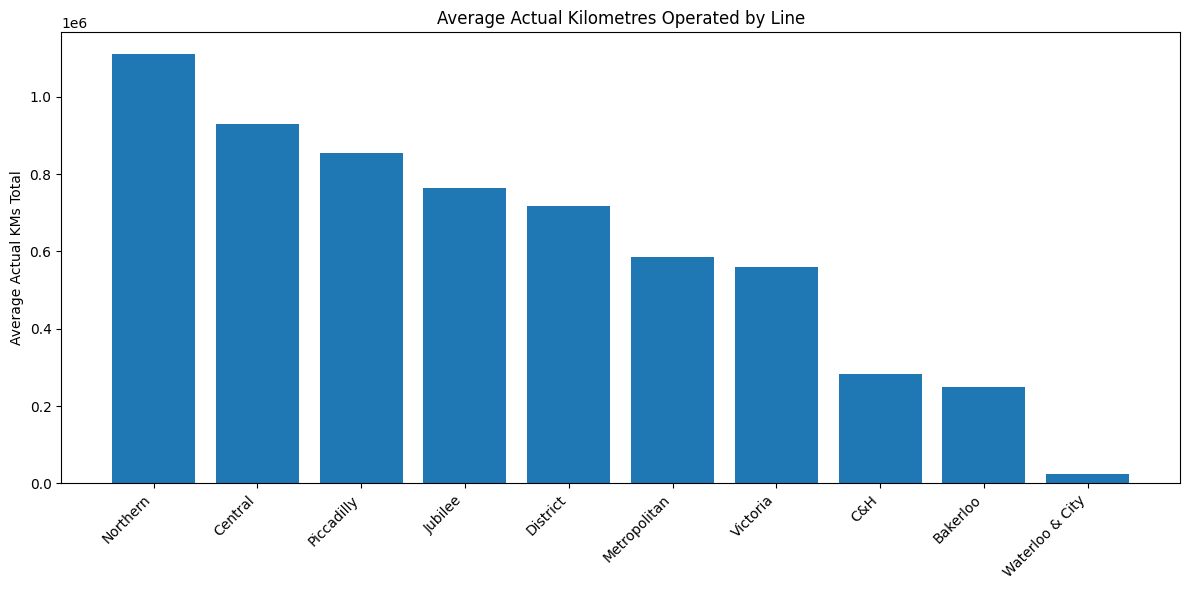

In [15]:
plt.figure(figsize=(12, 6))
plt.bar(
    km_line_summary["Line"],
    km_line_summary["Actual KMs Total"]
)
plt.xticks(rotation=45, ha="right")
plt.ylabel("Average Actual KMs Total")
plt.title("Average Actual Kilometres Operated by Line")
plt.tight_layout()
plt.savefig(OUTPUTS_DIR / "avg_actual_km_by_line.png")
plt.show()

In [16]:
km_comparison = (
    km.groupby("Line", as_index=False)[["Actual KMs Total", "Scheduled KMs Total"]]
    .mean()
)

km_comparison["km_delivery_ratio"] = (
    km_comparison["Actual KMs Total"] / km_comparison["Scheduled KMs Total"]
)

km_comparison = km_comparison.sort_values("km_delivery_ratio", ascending=True)
km_comparison.head(15)

,Line,Actual KMs Total,Scheduled KMs Total,km_delivery_ratio
1,C&H,2.841028e+05,3.244039e+05,0.875769
7,Piccadilly,8.555327e+05,9.561488e+05,0.894769
2,Central,9.298378e+05,1.023785e+06,0.908235
0,Bakerloo,2.502812e+05,2.743908e+05,0.912134
4,Jubilee,7.648197e+05,8.318303e+05,0.919442
5,Metropolitan,5.868405e+05,6.354110e+05,0.923560
8,Victoria,5.586965e+05,6.042296e+05,0.924643
3,District,7.174135e+05,7.710756e+05,0.930406
6,Northern,1.111561e+06,1.162608e+06,0.956093
9,Waterloo & City,2.357865e+04,2.425124e+04,0.972266


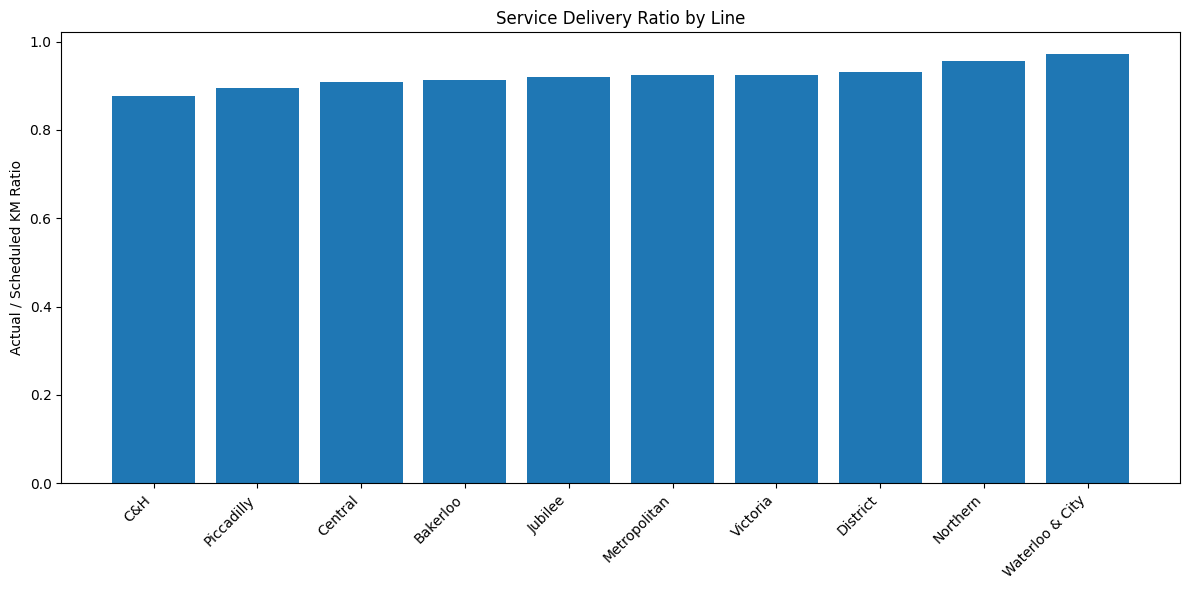

In [17]:
plt.figure(figsize=(12, 6))
plt.bar(
    km_comparison["Line"],
    km_comparison["km_delivery_ratio"]
)
plt.xticks(rotation=45, ha="right")
plt.ylabel("Actual / Scheduled KM Ratio")
plt.title("Service Delivery Ratio by Line")
plt.tight_layout()
plt.savefig(OUTPUTS_DIR / "km_delivery_ratio_by_line.png")
plt.show()

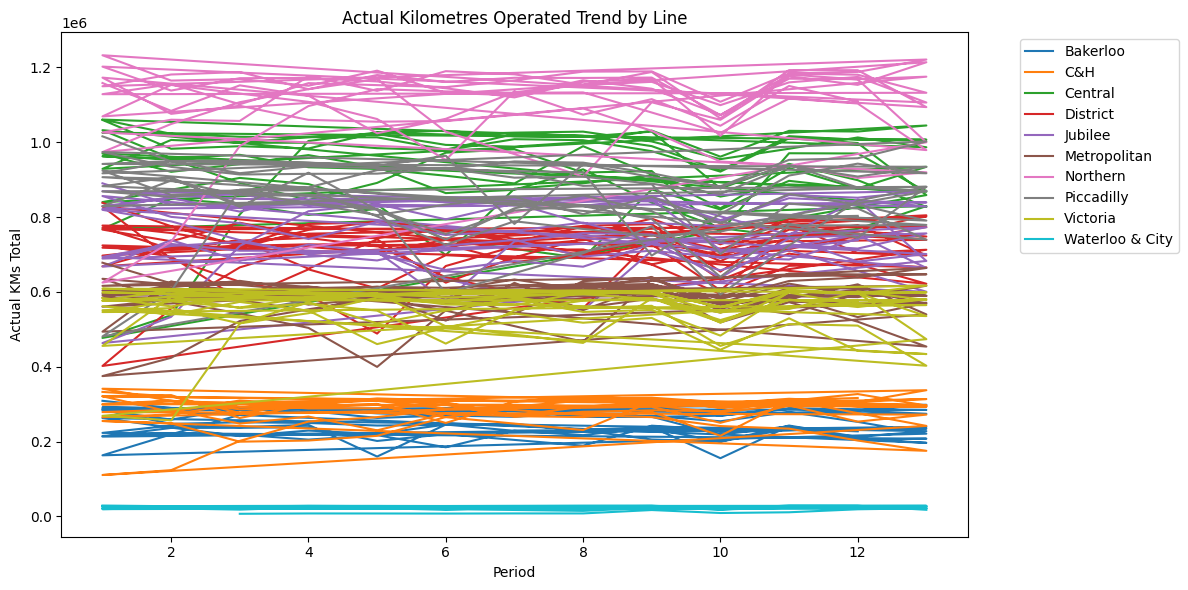

In [18]:
km["Period"] = pd.to_numeric(km["Period"], errors="coerce")

plt.figure(figsize=(12, 6))
for line in km["Line"].dropna().unique():
    subset = km[km["Line"] == line]
    plt.plot(
        subset["Period"],
        subset["Actual KMs Total"],
        label=line
    )

plt.xlabel("Period")
plt.ylabel("Actual KMs Total")
plt.title("Actual Kilometres Operated Trend by Line")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.savefig(OUTPUTS_DIR / "actual_km_trend_by_line.png")
plt.show()

In [19]:
ejt_line_summary = (
    ejt.groupby("Line", as_index=False)["EJT for Period"]
    .mean()
    .sort_values("EJT for Period", ascending=False)
)

ejt_line_summary.head(15)

,Line,EJT for Period
5,London Underground Network,4.689216
2,Circle and Hammersmith,3.513137
3,District,3.404706
8,Piccadilly,3.170784
1,Central,2.980588
6,Metropolitan,2.364118
0,Bakerloo,1.823922
4,Jubilee,1.475686
7,Northern,1.453137
9,Victoria,1.289020


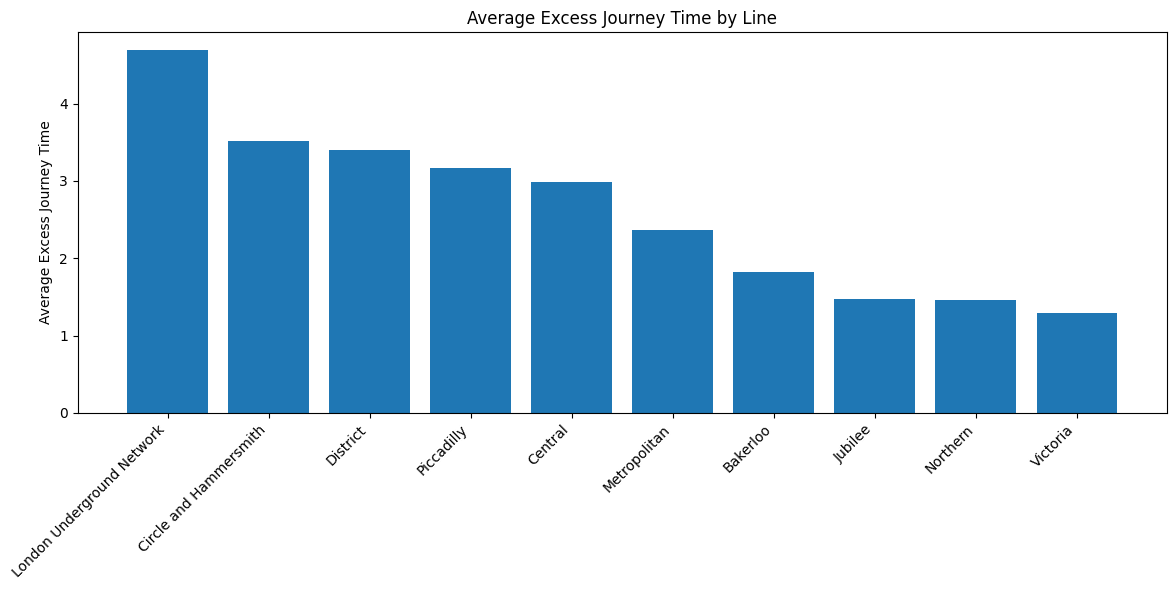

In [20]:
plt.figure(figsize=(12, 6))
plt.bar(
    ejt_line_summary["Line"],
    ejt_line_summary["EJT for Period"]
)
plt.xticks(rotation=45, ha="right")
plt.ylabel("Average Excess Journey Time")
plt.title("Average Excess Journey Time by Line")
plt.tight_layout()
plt.savefig(OUTPUTS_DIR / "avg_excess_journey_time_by_line.png")
plt.show()

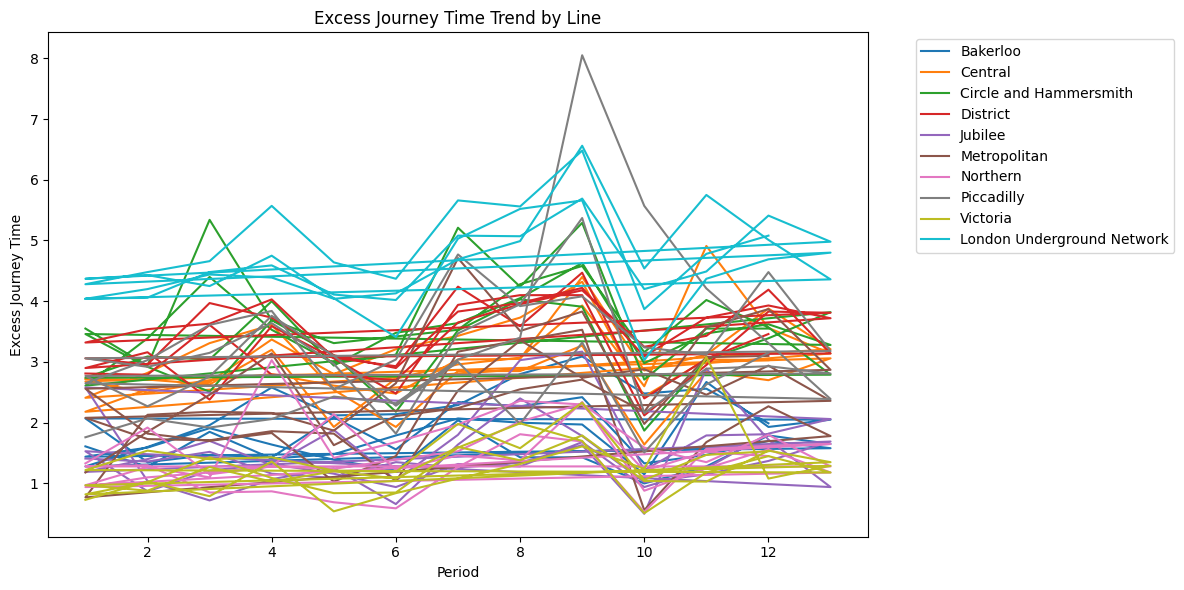

In [21]:
ejt["Period"] = pd.to_numeric(ejt["Period"], errors="coerce")

plt.figure(figsize=(12, 6))
for line in ejt["Line"].dropna().unique():
    subset = ejt[ejt["Line"] == line]
    plt.plot(
        subset["Period"],
        subset["EJT for Period"],
        label=line
    )

plt.xlabel("Period")
plt.ylabel("Excess Journey Time")
plt.title("Excess Journey Time Trend by Line")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.savefig(OUTPUTS_DIR / "ejt_trend_by_line.png")
plt.show()

## Step 4: Save summary outputs

These summary tables are used in the visuals notebook and help support line-level insights in the final report.

In [22]:
service_line_summary.to_csv(PROCESSED_DIR / "service_line_summary.csv", index=False)
km_line_summary.to_csv(PROCESSED_DIR / "km_line_summary.csv", index=False)
km_comparison.to_csv(PROCESSED_DIR / "km_comparison_summary.csv", index=False)
ejt_line_summary.to_csv(PROCESSED_DIR / "ejt_line_summary.csv", index=False)

print("Saved service_line_summary.csv")
print("Saved km_line_summary.csv")
print("Saved km_comparison_summary.csv")
print("Saved ejt_line_summary.csv")

Saved service_line_summary.csv
Saved km_line_summary.csv
Saved km_comparison_summary.csv
Saved ejt_line_summary.csv
